#### low + high frequency

Training model...
device: cuda


100%|██████████| 100001/100001 [02:03<00:00, 807.31it/s]



Final metrics:
Train_MSE 0.0008442932739853859
Test_MSE 0.00087857695
Low_MSE 9.37298e-06
High_MSE 6.685949e-05
Low_Rel_MSE 7.499659e-05
High_Rel_MSE 0.0021391963
Low_Amp 0.5004915
High_Amp 0.23882921
Low_Phase 0.408598
High_Phase 1.1122283
Low_Corr 0.9999630227434443
High_Corr 0.9999252513974385
Residual_Energy 0.0008019559

Saved checkpoints: 5001
Final step: 100000


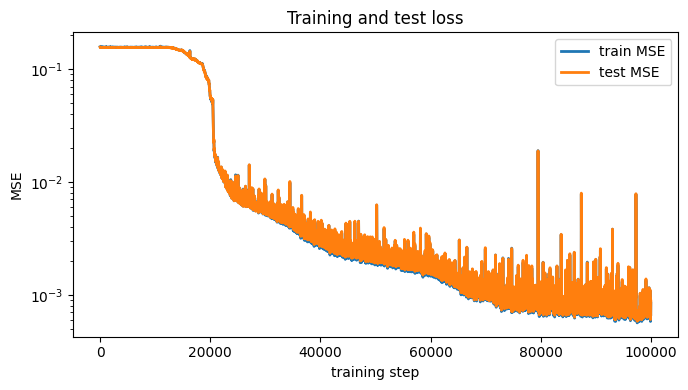

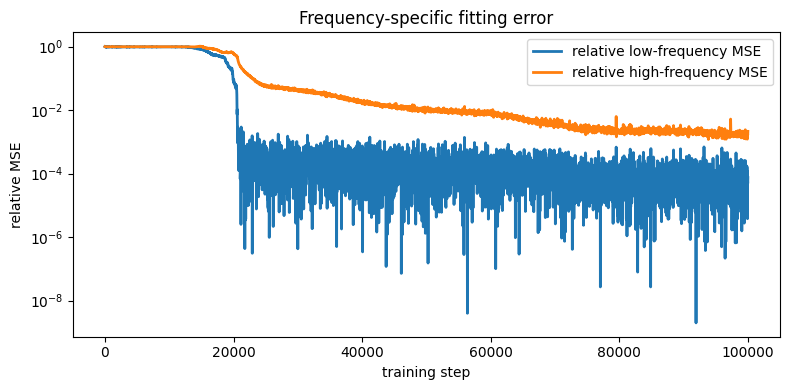

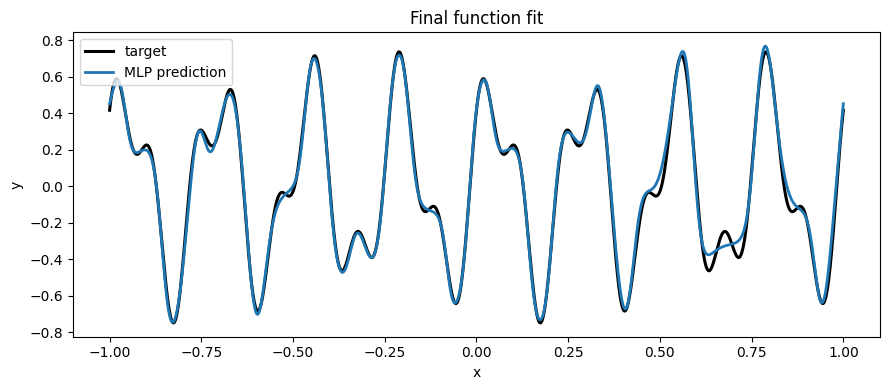

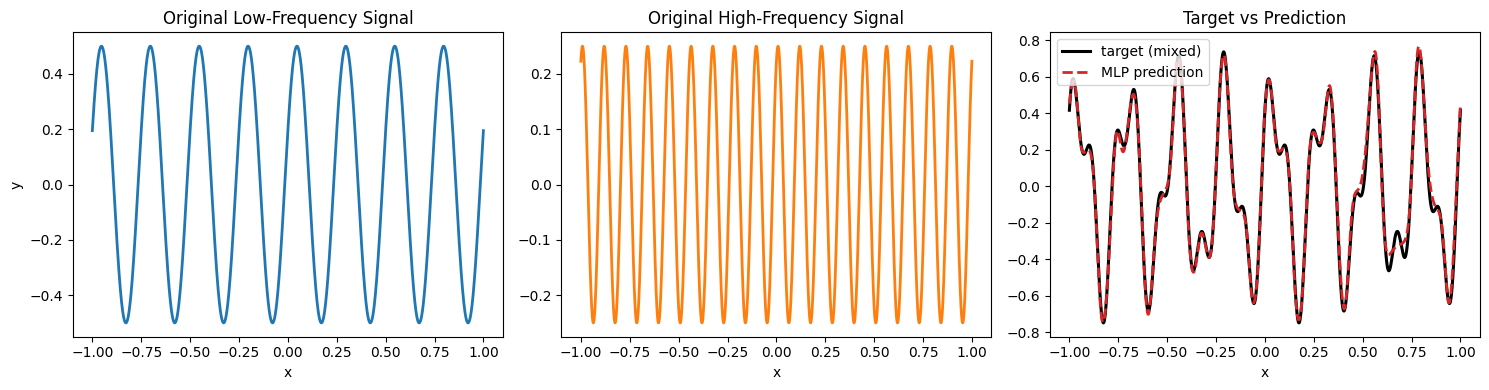

Extracting all-pair activation-FC trajectories...


100%|██████████| 5001/5001 [00:08<00:00, 579.16it/s]



FC definition: activation_correlation
Main dynamic measure: decorrelation = 1 - abs(FC)


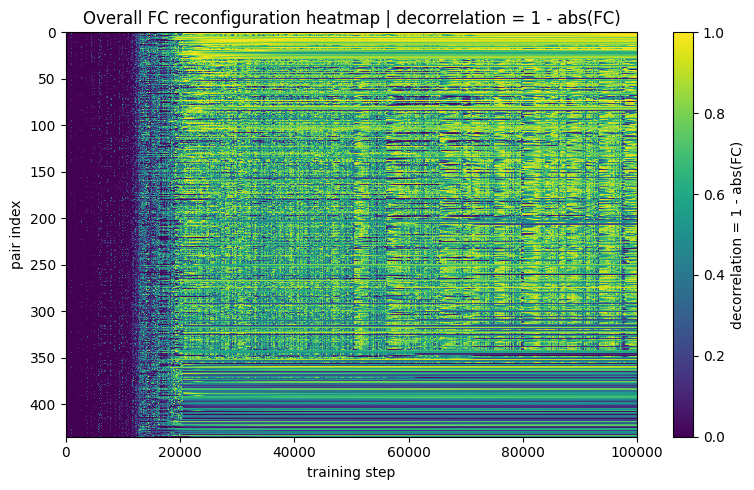


Pair class counts:
class
other                               359
late_reconfiguration_fluctuating     44
early_decorrelation_then_stable      32
Name: count, dtype: int64

Selected pair counts:
early_decorrelation_then_stable pairs: 32
late_reconfiguration_fluctuating pairs: 44


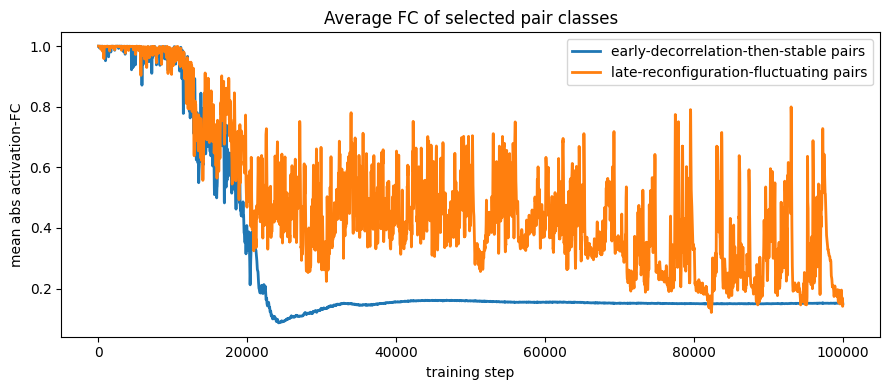

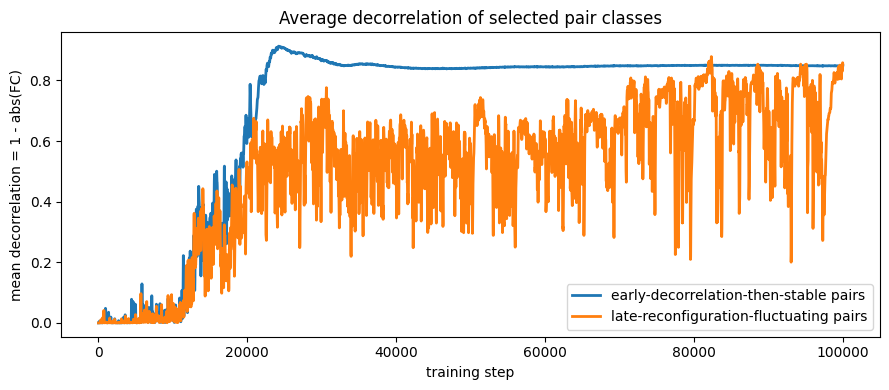


Early group neuron ids:
[4, 13, 6, 29, 20, 16, 23, 24, 28, 7, 11, 18, 9, 5, 19, 17, 10, 3]

Late group neuron ids:
[15, 2, 12, 22, 8, 25, 16, 20, 19, 26, 7, 11, 18, 9, 28, 0, 21, 27]

Neuron group partition:
early only: 10
late only: 10
overlap: 8
unselected: 2
early only ids: [3, 4, 5, 6, 10, 13, 17, 23, 24, 29]
late only ids: [0, 2, 8, 12, 15, 21, 22, 25, 26, 27]
overlap ids: [7, 9, 11, 16, 18, 19, 20, 28]
unselected ids: [1, 14]


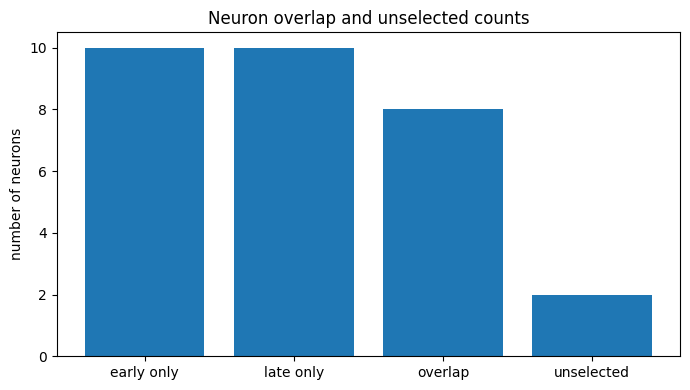


Group: early_decorrelation_then_stable
Number of neurons: 18
Neuron ids: [3, 4, 5, 6, 7, 9, 10, 11, 13, 16, 17, 18, 19, 20, 23, 24, 28, 29]
Low-frequency fraction: 1.0451841354370117
High-frequency fraction: 0.9282152652740479
Abs low-frequency fraction: 1.0451841354370117
Abs high-frequency fraction: 0.9282152652740479
Frequency selectivity: -0.059272780827215266

Group: late_reconfiguration_fluctuating
Number of neurons: 18
Neuron ids: [0, 2, 7, 8, 9, 11, 12, 15, 16, 18, 19, 20, 21, 22, 25, 26, 27, 28]
Low-frequency fraction: 0.09068171679973602
High-frequency fraction: 0.26367008686065674
Abs low-frequency fraction: 0.09068171679973602
Abs high-frequency fraction: 0.26367008686065674
Frequency selectivity: 0.4881825583318404


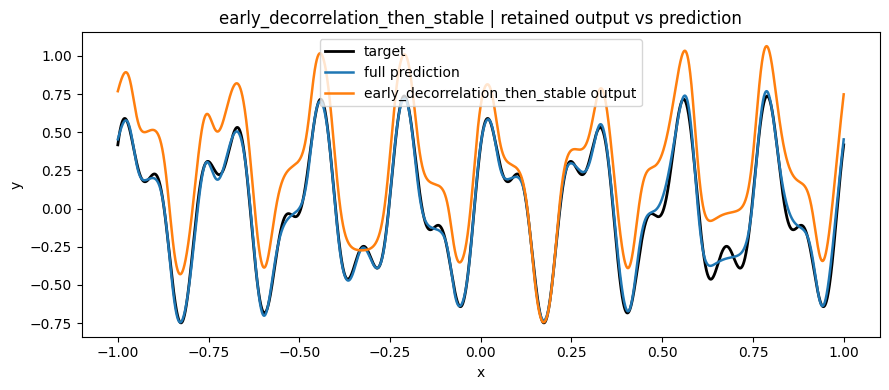

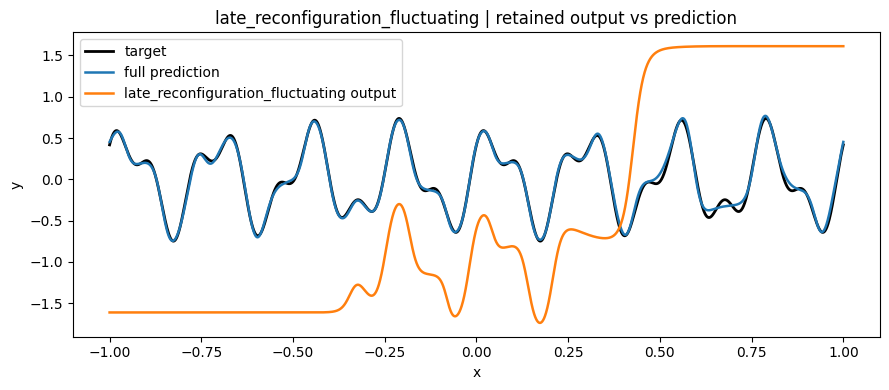

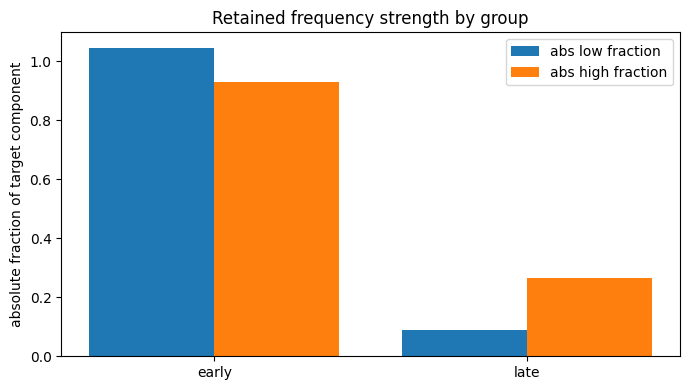

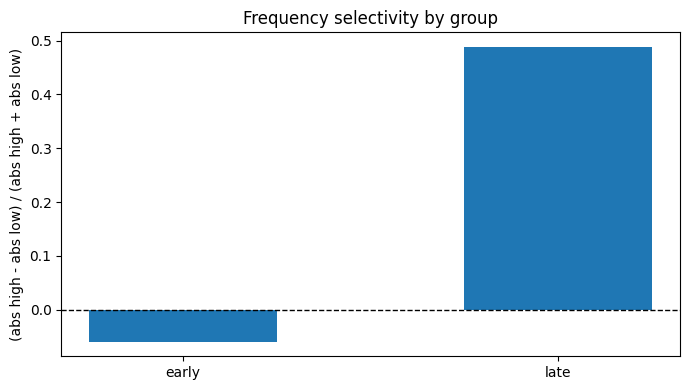

In [1]:
import warnings
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.init as init
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d

warnings.filterwarnings("ignore")


# ============================================================
# 0. Reproducibility and data
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def low_component(x):
    return 0.50 * np.sin(8 * np.pi * x + 0.4)


def high_component(x):
    return 0.25 * np.sin(18 * np.pi * x + 1.1)


def target_function(x):
    return low_component(x) + high_component(x)


low_freq = 4
high_freq = 9

domain = (-1.0, 1.0)
n_train = 4096
n_test = 4096

x_train_np = np.random.uniform(
    domain[0], domain[1], size=(n_train, 1)
).astype(np.float32)
x_train_np = np.sort(x_train_np, axis=0)
y_train_np = target_function(x_train_np).astype(np.float32)

x_test_np = np.linspace(domain[0], domain[1], n_test).reshape(-1, 1).astype(np.float32)
y_test_low_np = low_component(x_test_np).astype(np.float32)
y_test_high_np = high_component(x_test_np).astype(np.float32)
y_test_np = target_function(x_test_np).astype(np.float32)

x_train = torch.tensor(x_train_np).to(device)
y_train = torch.tensor(y_train_np).to(device)
x_test = torch.tensor(x_test_np).to(device)
y_test = torch.tensor(y_test_np).to(device)


# ============================================================
# 1. Model
# ============================================================

class RegressionMLP(nn.Module):
    def __init__(
        self,
        input_size=1,
        hidden_dims=None,
        output_size=1,
        activation="tanh",
        do_init=True,
        init_method="normal",
        init_scale=0.02,
        bias_init="zero",
        bias_scale=0.0,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [30, 30]

        self.hidden_dims = hidden_dims
        self.linear_layers = nn.ModuleList()
        self.activation_name = activation
        self.init_scale = init_scale
        self.bias_init = bias_init
        self.bias_scale = bias_scale

        layers = []
        current_dim = input_size

        for h_dim in hidden_dims:
            linear = nn.Linear(current_dim, h_dim)
            self.linear_layers.append(linear)
            layers.append(linear)
            layers.append(self._get_activation(activation))
            current_dim = h_dim

        output_layer = nn.Linear(current_dim, output_size)
        self.linear_layers.append(output_layer)
        layers.append(output_layer)

        self.network = nn.Sequential(*layers)

        if do_init:
            self._initialize_weights(init_method)

    def _get_activation(self, name):
        name = name.lower()
        if name == "tanh":
            return nn.Tanh()
        if name == "relu":
            return nn.ReLU()
        if name == "sigmoid":
            return nn.Sigmoid()
        if name == "leaky_relu":
            return nn.LeakyReLU()
        return nn.Tanh()

    def _initialize_weights(self, method):
        method = method.lower()

        for m in self.modules():
            if isinstance(m, nn.Linear):
                if method == "normal":
                    init.normal_(m.weight, mean=0.0, std=self.init_scale)
                elif method == "xavier":
                    init.xavier_normal_(m.weight)
                elif method == "kaiming":
                    init.kaiming_normal_(m.weight, nonlinearity="relu")
                elif method == "orthogonal":
                    init.orthogonal_(m.weight)
                else:
                    raise ValueError("Unknown init_method.")

                if m.bias is not None:
                    if self.bias_init == "zero":
                        init.constant_(m.bias, 0.0)
                    elif self.bias_init == "normal":
                        init.normal_(m.bias, mean=0.0, std=self.bias_scale)
                    else:
                        raise ValueError("Unknown bias_init.")

    def forward(self, x):
        return self.network(x)

    def get_hidden_activations(self, x):
        activations = []
        h = x

        for layer in self.network:
            h = layer(h)
            if isinstance(layer, (nn.Tanh, nn.ReLU, nn.Sigmoid, nn.LeakyReLU)):
                activations.append(h.clone())

        return activations


# ============================================================
# 2. Frequency projection and training metrics
# ============================================================

def project_frequency_component(x_np, y_np, freq):
    x = x_np.reshape(-1)
    y = y_np.reshape(-1)

    basis = np.stack(
        [
            np.sin(2 * np.pi * freq * x),
            np.cos(2 * np.pi * freq * x),
        ],
        axis=1,
    )

    coef, _, _, _ = np.linalg.lstsq(basis, y, rcond=None)
    fitted = basis @ coef
    amp = np.sqrt(coef[0] ** 2 + coef[1] ** 2)
    phase = np.arctan2(coef[1], coef[0])

    return fitted.reshape(-1, 1), coef, amp, phase


def evaluate_full_metrics(model):
    model.eval()

    with torch.no_grad():
        y_pred_np = model(x_test).detach().cpu().numpy()
        train_mse = torch.mean((model(x_train) - y_train) ** 2).item()

    pred_low, _, low_amp, low_phase = project_frequency_component(
        x_np=x_test_np,
        y_np=y_pred_np,
        freq=low_freq,
    )

    pred_high, _, high_amp, high_phase = project_frequency_component(
        x_np=x_test_np,
        y_np=y_pred_np,
        freq=high_freq,
    )

    residual = y_pred_np - pred_low - pred_high

    test_mse = np.mean((y_pred_np - y_test_np) ** 2)
    low_mse = np.mean((pred_low - y_test_low_np) ** 2)
    high_mse = np.mean((pred_high - y_test_high_np) ** 2)

    low_target_energy = np.mean(y_test_low_np ** 2)
    high_target_energy = np.mean(y_test_high_np ** 2)

    low_rel_mse = low_mse / (low_target_energy + 1e-12)
    high_rel_mse = high_mse / (high_target_energy + 1e-12)

    low_corr = np.corrcoef(pred_low.reshape(-1), y_test_low_np.reshape(-1))[0, 1]
    high_corr = np.corrcoef(pred_high.reshape(-1), y_test_high_np.reshape(-1))[0, 1]

    return {
        "Train_MSE": train_mse,
        "Test_MSE": test_mse,
        "Low_MSE": low_mse,
        "High_MSE": high_mse,
        "Low_Rel_MSE": low_rel_mse,
        "High_Rel_MSE": high_rel_mse,
        "Low_Amp": low_amp,
        "High_Amp": high_amp,
        "Low_Phase": low_phase,
        "High_Phase": high_phase,
        "Low_Corr": np.nan_to_num(low_corr),
        "High_Corr": np.nan_to_num(high_corr),
        "Residual_Energy": np.mean(residual ** 2),
    }


def train_regression_model(
    model,
    num_steps=100000,
    learning_rate=1e-2,
    batch_size=512,
    record_interval=20,
):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    test_losses = []
    sampled_steps = []
    models = []
    freq_history = []

    print("Training model...")
    print("device:", device)

    for step in tqdm(range(num_steps + 1)):
        idx = torch.randint(0, x_train.shape[0], size=(batch_size,), device=device)
        xb = x_train[idx]
        yb = y_train[idx]

        model.train()
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % record_interval == 0:
            metrics = evaluate_full_metrics(model)

            train_losses.append(metrics["Train_MSE"])
            test_losses.append(metrics["Test_MSE"])
            sampled_steps.append(step)
            freq_history.append(metrics)

            state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            models.append(state)

    return (
        np.array(train_losses),
        np.array(test_losses),
        np.array(sampled_steps),
        models,
        freq_history,
    )


def freq_history_to_arrays(freq_history):
    keys = list(freq_history[0].keys())
    out = {}
    for k in keys:
        out[k] = np.array([h[k] for h in freq_history])
    return out


# ============================================================
# 3. Basic plots: loss, frequency fitting, final prediction
# ============================================================

def plot_loss_curves(sampled_steps, train_losses, test_losses):
    plt.figure(figsize=(7, 4))
    plt.plot(sampled_steps, train_losses, linewidth=2, label="train MSE")
    plt.plot(sampled_steps, test_losses, linewidth=2, label="test MSE")
    plt.yscale("log")
    plt.xlabel("training step")
    plt.ylabel("MSE")
    plt.title("Training and test loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_frequency_fitting_curves(sampled_steps, freq_arrays):
    plt.figure(figsize=(8, 4))
    plt.plot(
        sampled_steps,
        freq_arrays["Low_Rel_MSE"],
        linewidth=2,
        label="relative low-frequency MSE",
    )
    plt.plot(
        sampled_steps,
        freq_arrays["High_Rel_MSE"],
        linewidth=2,
        label="relative high-frequency MSE",
    )
    plt.yscale("log")
    plt.xlabel("training step")
    plt.ylabel("relative MSE")
    plt.title("Frequency-specific fitting error")
    plt.legend()
    plt.tight_layout()
    plt.show()


def load_model_from_checkpoint(ckpt_idx):
    model = RegressionMLP(
        input_size=1,
        hidden_dims=hidden_dims,
        output_size=1,
        activation=act,
        do_init=False,
        init_method=init_method,
        init_scale=init_scale,
        bias_init=bias_init,
        bias_scale=bias_scale,
    ).to(device)

    model.load_state_dict(models[ckpt_idx])
    model.eval()
    return model


def plot_final_prediction(final_model):
    final_model.eval()
    with torch.no_grad():
        y_pred_np = final_model(x_test).detach().cpu().numpy()

    plt.figure(figsize=(9, 4))
    plt.plot(x_test_np, y_test_np, color="black", linewidth=2.2, label="target")
    plt.plot(x_test_np, y_pred_np, linewidth=2, label="MLP prediction")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Final function fit")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return y_pred_np


def print_final_metrics(freq_history):
    print("\nFinal metrics:")
    for k, v in freq_history[-1].items():
        print(k, v)

def plot_signals_breakdown(x_np, y_low_np, y_high_np, y_target_np, y_pred_np):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. 绘制原始低频信号
    axes[0].plot(x_np, y_low_np, color="tab:blue", linewidth=2)
    axes[0].set_title("Original Low-Frequency Signal")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    # 2. 绘制原始高频信号
    axes[1].plot(x_np, y_high_np, color="tab:orange", linewidth=2)
    axes[1].set_title("Original High-Frequency Signal")
    axes[1].set_xlabel("x")

    # 3. 绘制混合后的目标信号与MLP拟合信号的对比
    axes[2].plot(x_np, y_target_np, color="black", linewidth=2.2, label="target (mixed)")
    axes[2].plot(x_np, y_pred_np, color="tab:red", linewidth=2, linestyle="--", label="MLP prediction")
    axes[2].set_title("Target vs Prediction")
    axes[2].set_xlabel("x")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# 4. FC extraction and classification
# ============================================================

def corrcoef_columns(x, eps=1e-12):
    x = np.asarray(x, dtype=float)
    x = x - x.mean(axis=0, keepdims=True)
    std = x.std(axis=0, ddof=1, keepdims=True)
    z = x / np.maximum(std, eps)
    c = (z.T @ z) / max(z.shape[0] - 1, 1)
    c = np.nan_to_num(c)
    np.fill_diagonal(c, 1.0)
    return c


def get_activation_fc(model, x_data, layer_index=1, max_samples=2048):
    model.eval()

    if max_samples is not None and x_data.shape[0] > max_samples:
        idx = torch.linspace(
            0,
            x_data.shape[0] - 1,
            steps=max_samples,
            device=x_data.device,
        ).long()
        x_used = x_data[idx]
    else:
        x_used = x_data

    with torch.no_grad():
        acts = model.get_hidden_activations(x_used)[layer_index]
        acts = acts.detach().cpu().numpy()

    return corrcoef_columns(acts)


def extract_all_pair_fc_trajectories(
    layer_index=1,
    max_samples=2048,
    step_interval=1,
    smooth_sigma=1.0,
):
    hidden_size = hidden_dims[layer_index]
    row_idx, col_idx = np.triu_indices(hidden_size, k=1)

    steps = []
    fc_signed_vecs = []
    fc_abs_vecs = []
    decorr_vecs = []

    print("Extracting all-pair activation-FC trajectories...")

    for ckpt in tqdm(range(0, len(models), step_interval)):
        model = load_model_from_checkpoint(ckpt)

        fc_mat = get_activation_fc(
            model=model,
            x_data=x_test,
            layer_index=layer_index,
            max_samples=max_samples,
        )

        fc_signed_vec = fc_mat[row_idx, col_idx]
        fc_abs_vec = np.abs(fc_signed_vec)
        decorr_vec = 1.0 - fc_abs_vec

        fc_signed_vecs.append(fc_signed_vec)
        fc_abs_vecs.append(fc_abs_vec)
        decorr_vecs.append(decorr_vec)
        steps.append(sampled_steps[ckpt])

    fc_signed_vecs = np.array(fc_signed_vecs)
    fc_abs_vecs = np.array(fc_abs_vecs)
    decorr_vecs = np.array(decorr_vecs)
    steps = np.array(steps)

    if smooth_sigma is not None and smooth_sigma > 0:
        fc_signed_smooth = gaussian_filter1d(fc_signed_vecs, sigma=smooth_sigma, axis=0)
        fc_abs_smooth = gaussian_filter1d(fc_abs_vecs, sigma=smooth_sigma, axis=0)
        decorr_smooth = gaussian_filter1d(decorr_vecs, sigma=smooth_sigma, axis=0)
    else:
        fc_signed_smooth = fc_signed_vecs.copy()
        fc_abs_smooth = fc_abs_vecs.copy()
        decorr_smooth = decorr_vecs.copy()

    return {
        "steps": steps,
        "fc_signed_vecs": fc_signed_vecs,
        "fc_abs_vecs": fc_abs_vecs,
        "decorr_vecs": decorr_vecs,
        "fc_signed_smooth": fc_signed_smooth,
        "fc_abs_smooth": fc_abs_smooth,
        "decorr_smooth": decorr_smooth,
        "row_idx": row_idx,
        "col_idx": col_idx,
        "hidden_size": hidden_size,
        "fc_definition": "activation_correlation",
        "main_dynamic_measure": "decorrelation = 1 - abs(FC)",
    }


def rank01(v):
    v = np.asarray(v, dtype=float)
    order = np.argsort(v)
    r = np.empty_like(order, dtype=float)
    r[order] = np.arange(len(v), dtype=float)
    return r / max(len(v) - 1, 1)


def compute_fc_dynamic_metrics(pair_data, early_frac=0.35, late_frac=0.55):
    steps = np.asarray(pair_data["steps"], dtype=float)
    fc_abs = np.asarray(pair_data["fc_abs_smooth"], dtype=float)
    fc_signed = np.asarray(pair_data["fc_signed_smooth"], dtype=float)
    decorr = np.asarray(pair_data["decorr_smooth"], dtype=float)

    eps = 1e-12
    t = (steps - steps[0]) / (steps[-1] - steps[0] + eps)

    d_abs_fc = np.abs(np.diff(fc_abs, axis=0))
    d_decorr = np.abs(np.diff(decorr, axis=0))

    total_reconfiguration = d_abs_fc.sum(axis=0)
    total_decorr_change = d_decorr.sum(axis=0)

    total_reconfiguration_safe = total_reconfiguration + eps
    total_decorr_change_safe = total_decorr_change + eps

    dt_mid = 0.5 * (t[:-1] + t[1:])

    change_center = (
        d_abs_fc * dt_mid[:, None]
    ).sum(axis=0) / total_reconfiguration_safe

    late_mask_time = t[1:] >= late_frac
    late_change_frac = d_abs_fc[late_mask_time].sum(axis=0) / total_reconfiguration_safe

    cum_decorr_change = np.cumsum(d_decorr, axis=0) / total_decorr_change_safe[None, :]
    idx80 = np.argmax(cum_decorr_change >= 0.80, axis=0)
    t80_decorr = t[1:][idx80]

    valid_decorr = total_decorr_change > 1e-10
    t80_decorr[~valid_decorr] = 1.0

    post_early_decorr_std = decorr[t >= early_frac].std(axis=0)
    post_late_abs_fc_std = fc_abs[t >= late_frac].std(axis=0)

    tail_mask = t >= 0.85
    tail_decorr = decorr[tail_mask].mean(axis=0)

    initial_decorr = decorr[0]
    final_decorr = decorr[-1]
    max_decorr = decorr.max(axis=0)
    final_abs_fc = fc_abs[-1]
    final_signed_fc = fc_signed[-1]

    peak_decorr_time = t[np.argmax(decorr, axis=0)]

    return {
        "t": t,
        "fc_abs": fc_abs,
        "fc_signed": fc_signed,
        "decorr": decorr,
        "initial_decorr": initial_decorr,
        "final_decorr": final_decorr,
        "tail_decorr": tail_decorr,
        "max_decorr": max_decorr,
        "peak_decorr_time": peak_decorr_time,
        "t80_decorr": t80_decorr,
        "total_reconfiguration": total_reconfiguration,
        "total_decorr_change": total_decorr_change,
        "change_center": change_center,
        "late_change_frac": late_change_frac,
        "post_early_decorr_std": post_early_decorr_std,
        "post_late_abs_fc_std": post_late_abs_fc_std,
        "final_abs_fc": final_abs_fc,
        "final_signed_fc": final_signed_fc,
    }


def sort_pairs_by_fc_dynamics(pair_data, mode="max_decorrelation"):
    metrics = compute_fc_dynamic_metrics(pair_data)

    if mode == "max_decorrelation":
        score = metrics["max_decorr"]
    elif mode == "late_reconfiguration":
        score = metrics["late_change_frac"]
    elif mode == "total_reconfiguration":
        score = metrics["total_reconfiguration"]
    elif mode == "change_center":
        score = metrics["change_center"]
    else:
        raise ValueError("Unknown sorting mode.")

    order = np.argsort(score)[::-1]
    return order, score


def plot_fc_heatmap(pair_data, sort_mode="max_decorrelation"):
    steps = pair_data["steps"]
    mat = pair_data["decorr_smooth"]

    order, _ = sort_pairs_by_fc_dynamics(pair_data, mode=sort_mode)
    mat_ordered = mat[:, order].T

    plt.figure(figsize=(8, 5))
    im = plt.imshow(
        mat_ordered,
        aspect="auto",
        interpolation="nearest",
        cmap="viridis",
        vmin=0,
        vmax=1,
        extent=[steps[0], steps[-1], mat_ordered.shape[0], 0],
    )
    plt.xlabel("training step")
    plt.ylabel("pair index")
    plt.title("Overall FC reconfiguration heatmap | decorrelation = 1 - abs(FC)")
    cbar = plt.colorbar(im)
    cbar.set_label("decorrelation = 1 - abs(FC)")
    plt.tight_layout()
    plt.show()


def classify_fc_pairs_by_reconfiguration(
    pair_data,
    early_frac=0.35,
    late_frac=0.55,
    top_frac=0.10,
    min_pairs=10,
):
    row_idx = np.asarray(pair_data["row_idx"])
    col_idx = np.asarray(pair_data["col_idx"])
    metrics = compute_fc_dynamic_metrics(
        pair_data,
        early_frac=early_frac,
        late_frac=late_frac,
    )

    P = len(row_idx)

    max_decorr = metrics["max_decorr"]
    tail_decorr = metrics["tail_decorr"]
    t80_decorr = metrics["t80_decorr"]
    total_reconfiguration = metrics["total_reconfiguration"]
    change_center = metrics["change_center"]
    late_change_frac = metrics["late_change_frac"]
    post_early_decorr_std = metrics["post_early_decorr_std"]
    post_late_abs_fc_std = metrics["post_late_abs_fc_std"]

    high_decorr_thr = np.quantile(max_decorr, 0.65)
    tail_decorr_thr = np.quantile(tail_decorr, 0.55)
    stable_thr = np.quantile(post_early_decorr_std, 0.35)

    tv_thr = np.quantile(total_reconfiguration, 0.65)
    late_fluct_thr = np.quantile(post_late_abs_fc_std, 0.65)

    hard_early = (
        (max_decorr >= high_decorr_thr)
        & (tail_decorr >= tail_decorr_thr)
        & (t80_decorr <= early_frac)
        & (post_early_decorr_std <= stable_thr)
    )

    hard_late = (
        (total_reconfiguration >= tv_thr)
        & (change_center >= late_frac)
        & (late_change_frac >= 0.45)
        & (post_late_abs_fc_std >= late_fluct_thr)
    )

    early_score = (
        rank01(max_decorr)
        + rank01(tail_decorr)
        + rank01(-t80_decorr)
        + rank01(-post_early_decorr_std)
    )

    late_score = (
        rank01(total_reconfiguration)
        + rank01(change_center)
        + rank01(late_change_frac)
        + rank01(post_late_abs_fc_std)
    )

    n_select = max(min_pairs, int(np.ceil(top_frac * P)))

    early_candidates = np.where(hard_early)[0]
    if len(early_candidates) < min_pairs:
        early_ids = np.argsort(early_score)[::-1][:n_select]
    else:
        early_ids = early_candidates[
            np.argsort(early_score[early_candidates])[::-1][:n_select]
        ]

    early_set = set(early_ids.tolist())

    late_candidates = np.where(hard_late)[0]
    late_candidates = np.array([p for p in late_candidates if p not in early_set])

    if len(late_candidates) < min_pairs:
        late_order = [p for p in np.argsort(late_score)[::-1] if p not in early_set]
        late_ids = np.array(late_order[:n_select])
    else:
        late_ids = late_candidates[
            np.argsort(late_score[late_candidates])[::-1][:n_select]
        ]

    pair_df = pd.DataFrame({
        "pair_id": np.arange(P),
        "neuron_i": row_idx,
        "neuron_j": col_idx,
        "class": "other",
        "fc_abs_initial": metrics["fc_abs"][0],
        "fc_abs_final": metrics["final_abs_fc"],
        "fc_signed_initial": metrics["fc_signed"][0],
        "fc_signed_final": metrics["final_signed_fc"],
        "decorr_initial": metrics["initial_decorr"],
        "decorr_final": metrics["final_decorr"],
        "decorr_tail": tail_decorr,
        "decorr_max": max_decorr,
        "t80_decorr": t80_decorr,
        "total_reconfiguration": total_reconfiguration,
        "change_center": change_center,
        "late_change_frac": late_change_frac,
        "post_early_decorr_std": post_early_decorr_std,
        "post_late_abs_fc_std": post_late_abs_fc_std,
        "early_score": early_score,
        "late_score": late_score,
    })

    pair_df.loc[early_ids, "class"] = "early_decorrelation_then_stable"
    pair_df.loc[late_ids, "class"] = "late_reconfiguration_fluctuating"

    return pair_df, early_ids, late_ids


def summarize_selected_pair_fc(pair_data, pair_ids):
    pair_ids = np.asarray(pair_ids, dtype=int)
    steps = pair_data["steps"]
    fc_abs = pair_data["fc_abs_smooth"][:, pair_ids]
    decorr = pair_data["decorr_smooth"][:, pair_ids]

    return {
        "steps": steps,
        "n_pairs": len(pair_ids),
        "mean_abs_fc": fc_abs.mean(axis=1),
        "mean_decorr": decorr.mean(axis=1),
    }


def plot_selected_pair_average_fc(pair_data, early_pair_ids, late_pair_ids):
    early = summarize_selected_pair_fc(pair_data, early_pair_ids)
    late = summarize_selected_pair_fc(pair_data, late_pair_ids)

    print("\nSelected pair counts:")
    print("early_decorrelation_then_stable pairs:", early["n_pairs"])
    print("late_reconfiguration_fluctuating pairs:", late["n_pairs"])

    plt.figure(figsize=(9, 4))
    plt.plot(
        early["steps"],
        early["mean_abs_fc"],
        linewidth=2,
        label="early-decorrelation-then-stable pairs",
    )
    plt.plot(
        late["steps"],
        late["mean_abs_fc"],
        linewidth=2,
        label="late-reconfiguration-fluctuating pairs",
    )
    plt.xlabel("training step")
    plt.ylabel("mean abs activation-FC")
    plt.title("Average FC of selected pair classes")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(
        early["steps"],
        early["mean_decorr"],
        linewidth=2,
        label="early-decorrelation-then-stable pairs",
    )
    plt.plot(
        late["steps"],
        late["mean_decorr"],
        linewidth=2,
        label="late-reconfiguration-fluctuating pairs",
    )
    plt.xlabel("training step")
    plt.ylabel("mean decorrelation = 1 - abs(FC)")
    plt.title("Average decorrelation of selected pair classes")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 5. Neuron grouping and retained output analysis
# ============================================================

def neurons_from_pair_group(pair_df, pair_ids, score_col):
    pair_ids = np.asarray(pair_ids, dtype=int)

    if len(pair_ids) == 0:
        return pd.DataFrame(columns=[
            "neuron",
            "degree_count",
            "weighted_score",
            "normalized_score",
        ])

    sub = pair_df.set_index("pair_id").loc[pair_ids].reset_index()

    rows = []
    for _, r in sub.iterrows():
        s = float(r[score_col])
        rows.append({
            "neuron": int(r["neuron_i"]),
            "pair_id": int(r["pair_id"]),
            "pair_score": s,
        })
        rows.append({
            "neuron": int(r["neuron_j"]),
            "pair_id": int(r["pair_id"]),
            "pair_score": s,
        })

    out = pd.DataFrame(rows)
    out = (
        out.groupby("neuron")
        .agg(
            degree_count=("pair_id", "count"),
            weighted_score=("pair_score", "sum"),
        )
        .reset_index()
        .sort_values(["weighted_score", "degree_count"], ascending=False)
        .reset_index(drop=True)
    )

    out["normalized_score"] = out["weighted_score"] / (
        out["weighted_score"].sum() + 1e-12
    )

    return out


def get_group_partition(hidden_size, early_group_ids, late_group_ids):
    all_ids = set(range(hidden_size))
    early_set = set(map(int, early_group_ids))
    late_set = set(map(int, late_group_ids))

    early_only = sorted(list(early_set - late_set))
    late_only = sorted(list(late_set - early_set))
    overlap = sorted(list(early_set & late_set))
    selected_union = sorted(list(early_set | late_set))
    unselected = sorted(list(all_ids - (early_set | late_set)))

    return {
        "early": sorted(list(early_set)),
        "late": sorted(list(late_set)),
        "early_only": early_only,
        "late_only": late_only,
        "overlap": overlap,
        "selected_union": selected_union,
        "unselected": unselected,
    }


def plot_group_partition_counts(group_ids):
    labels = ["early only", "late only", "overlap", "unselected"]
    counts = [
        len(group_ids["early_only"]),
        len(group_ids["late_only"]),
        len(group_ids["overlap"]),
        len(group_ids["unselected"]),
    ]

    print("\nNeuron group partition:")
    for label, count in zip(labels, counts):
        print(label + ":", count)

    print("early only ids:", group_ids["early_only"])
    print("late only ids:", group_ids["late_only"])
    print("overlap ids:", group_ids["overlap"])
    print("unselected ids:", group_ids["unselected"])

    plt.figure(figsize=(7, 4))
    plt.bar(labels, counts)
    plt.ylabel("number of neurons")
    plt.title("Neuron overlap and unselected counts")
    plt.tight_layout()
    plt.show()


def get_model_output_np(ckpt_idx=-1, x_data=None):
    if x_data is None:
        x_data = x_test

    model = load_model_from_checkpoint(ckpt_idx)

    with torch.no_grad():
        y = model(x_data).detach().cpu().numpy()

    return y


def get_contribution_matrix_np(ckpt_idx=-1, layer_index=1, x_data=None):
    if x_data is None:
        x_data = x_test

    model = load_model_from_checkpoint(ckpt_idx)

    with torch.no_grad():
        acts = model.get_hidden_activations(x_data)[layer_index]
        acts = acts.detach().cpu().numpy()
        readout = model.linear_layers[-1].weight.detach().cpu().numpy().reshape(-1)

    return acts * readout.reshape(1, -1)


def target_fraction(coef, target_coef, eps=1e-12):
    return float(
        np.dot(coef, target_coef) / (np.dot(target_coef, target_coef) + eps)
    )


def project_to_target_bases(y_np):
    low_fit, low_coef, low_amp, low_phase = project_frequency_component(
        x_np=x_test_np,
        y_np=y_np,
        freq=low_freq,
    )

    high_fit, high_coef, high_amp, high_phase = project_frequency_component(
        x_np=x_test_np,
        y_np=y_np,
        freq=high_freq,
    )

    return {
        "low_fit": low_fit,
        "high_fit": high_fit,
        "low_coef": low_coef,
        "high_coef": high_coef,
        "low_amp": low_amp,
        "high_amp": high_amp,
        "low_phase": low_phase,
        "high_phase": high_phase,
    }


def get_group_retained_result(neuron_ids, group_name, ckpt_idx=-1, layer_index=1):
    neuron_ids = list(map(int, neuron_ids))

    y_full = get_model_output_np(ckpt_idx=ckpt_idx, x_data=x_test)

    contrib = get_contribution_matrix_np(
        ckpt_idx=ckpt_idx,
        layer_index=layer_index,
        x_data=x_test,
    )

    if len(neuron_ids) == 0:
        group_signal = np.zeros_like(y_full)
    else:
        group_signal = contrib[:, neuron_ids].sum(axis=1, keepdims=True)

    group_proj = project_to_target_bases(group_signal)

    _, target_low_coef, _, _ = project_frequency_component(
        x_np=x_test_np,
        y_np=y_test_low_np,
        freq=low_freq,
    )

    _, target_high_coef, _, _ = project_frequency_component(
        x_np=x_test_np,
        y_np=y_test_high_np,
        freq=high_freq,
    )

    retained_low_fraction = target_fraction(
        group_proj["low_coef"],
        target_low_coef,
    )

    retained_high_fraction = target_fraction(
        group_proj["high_coef"],
        target_high_coef,
    )

    abs_low_fraction = abs(retained_low_fraction)
    abs_high_fraction = abs(retained_high_fraction)

    frequency_selectivity = (
        abs_high_fraction - abs_low_fraction
    ) / (abs_high_fraction + abs_low_fraction + 1e-12)

    return {
        "group_name": group_name,
        "neuron_ids": neuron_ids,
        "n_neurons": len(neuron_ids),
        "y_full": y_full,
        "y_group": group_signal,
        "group_proj": group_proj,
        "retained_low_fraction": retained_low_fraction,
        "retained_high_fraction": retained_high_fraction,
        "abs_low_fraction": abs_low_fraction,
        "abs_high_fraction": abs_high_fraction,
        "frequency_selectivity": frequency_selectivity,
    }


def print_group_summary(result):
    print("\nGroup:", result["group_name"])
    print("Number of neurons:", result["n_neurons"])
    print("Neuron ids:", result["neuron_ids"])
    print("Low-frequency fraction:", result["retained_low_fraction"])
    print("High-frequency fraction:", result["retained_high_fraction"])
    print("Abs low-frequency fraction:", result["abs_low_fraction"])
    print("Abs high-frequency fraction:", result["abs_high_fraction"])
    print("Frequency selectivity:", result["frequency_selectivity"])


def plot_single_group_output(result):
    name = result["group_name"]

    plt.figure(figsize=(9, 4))
    plt.plot(x_test_np, y_test_np, color="black", linewidth=2.0, label="target")
    plt.plot(x_test_np, result["y_full"], linewidth=1.8, label="full prediction")
    plt.plot(x_test_np, result["y_group"], linewidth=1.8, label=name + " output")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(name + " | retained output vs prediction")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_group_frequency_bias(early_result, late_result):
    groups = ["early", "late"]
    low_abs = [early_result["abs_low_fraction"], late_result["abs_low_fraction"]]
    high_abs = [early_result["abs_high_fraction"], late_result["abs_high_fraction"]]
    selectivity = [
        early_result["frequency_selectivity"],
        late_result["frequency_selectivity"],
    ]

    x = np.arange(len(groups))

    plt.figure(figsize=(7, 4))
    plt.bar(x - 0.2, low_abs, width=0.4, label="abs low fraction")
    plt.bar(x + 0.2, high_abs, width=0.4, label="abs high fraction")
    plt.xticks(x, groups)
    plt.ylabel("absolute fraction of target component")
    plt.title("Retained frequency strength by group")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.bar(x, selectivity, width=0.5)
    plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
    plt.xticks(x, groups)
    plt.ylabel("(abs high - abs low) / (abs high + abs low)")
    plt.title("Frequency selectivity by group")
    plt.tight_layout()
    plt.show()


# ============================================================
# 6. Main execution
# ============================================================

hidden_dims = [30, 30]
act = "tanh"
init_method = "normal"
init_scale = 0.02
bias_init = "zero"
bias_scale = 0.0

learning_rate = 1e-2
num_steps = 100000
batch_size = 512
record_interval = 20

analysis_layer_index = 1
fc_max_samples = 2048
fc_step_interval = 1
fc_smooth_sigma = 1.0

early_frac = 0.35
late_frac = 0.55
top_frac = 0.10
min_pairs = 10

set_seed(42)

model = RegressionMLP(
    input_size=1,
    hidden_dims=hidden_dims,
    output_size=1,
    activation=act,
    do_init=True,
    init_method=init_method,
    init_scale=init_scale,
    bias_init=bias_init,
    bias_scale=bias_scale,
).to(device)

train_losses, test_losses, sampled_steps, models, freq_history = train_regression_model(
    model=model,
    num_steps=num_steps,
    learning_rate=learning_rate,
    batch_size=batch_size,
    record_interval=record_interval,
)

freq_arrays = freq_history_to_arrays(freq_history)
print_final_metrics(freq_history)
print("\nSaved checkpoints:", len(models))
print("Final step:", sampled_steps[-1])

# 1. Training and test loss
plot_loss_curves(sampled_steps, train_losses, test_losses)

# 2. Low- and high-frequency fitting degree
plot_frequency_fitting_curves(sampled_steps, freq_arrays)

# 3. Target curve vs model prediction
final_model = load_model_from_checkpoint(-1)
y_pred_np = plot_final_prediction(final_model)

# 调用新函数，绘制拆解后的三张图
plot_signals_breakdown(
    x_np=x_test_np,
    y_low_np=y_test_low_np,
    y_high_np=y_test_high_np,
    y_target_np=y_test_np,
    y_pred_np=y_pred_np
)

# 4. Overall FC heatmap
pair_dyn = extract_all_pair_fc_trajectories(
    layer_index=analysis_layer_index,
    max_samples=fc_max_samples,
    step_interval=fc_step_interval,
    smooth_sigma=fc_smooth_sigma,
)

print("\nFC definition:", pair_dyn["fc_definition"])
print("Main dynamic measure:", pair_dyn["main_dynamic_measure"])

plot_fc_heatmap(
    pair_data=pair_dyn,
    sort_mode="max_decorrelation",
)

# 5. FC pair classification and average FC of the two selected groups
pair_df, early_pair_ids, late_pair_ids = classify_fc_pairs_by_reconfiguration(
    pair_data=pair_dyn,
    early_frac=early_frac,
    late_frac=late_frac,
    top_frac=top_frac,
    min_pairs=min_pairs,
)

print("\nPair class counts:")
print(pair_df["class"].value_counts())

plot_selected_pair_average_fc(
    pair_data=pair_dyn,
    early_pair_ids=early_pair_ids,
    late_pair_ids=late_pair_ids,
)

# Convert selected FC-pair groups into non-exclusive neuron groups.
early_neurons = neurons_from_pair_group(
    pair_df=pair_df,
    pair_ids=early_pair_ids,
    score_col="early_score",
)

late_neurons = neurons_from_pair_group(
    pair_df=pair_df,
    pair_ids=late_pair_ids,
    score_col="late_score",
)

early_group_ids = early_neurons["neuron"].astype(int).tolist()
late_group_ids = late_neurons["neuron"].astype(int).tolist()

print("\nEarly group neuron ids:")
print(early_group_ids)

print("\nLate group neuron ids:")
print(late_group_ids)

# 6. Exclusive counts, overlap counts, and unselected-neuron counts
group_ids = get_group_partition(
    hidden_size=pair_dyn["hidden_size"],
    early_group_ids=early_group_ids,
    late_group_ids=late_group_ids,
)

plot_group_partition_counts(group_ids)

# 7. Non-exclusive group retained outputs, plotted separately.
early_result = get_group_retained_result(
    neuron_ids=group_ids["early"],
    group_name="early_decorrelation_then_stable",
    ckpt_idx=-1,
    layer_index=analysis_layer_index,
)

late_result = get_group_retained_result(
    neuron_ids=group_ids["late"],
    group_name="late_reconfiguration_fluctuating",
    ckpt_idx=-1,
    layer_index=analysis_layer_index,
)

print_group_summary(early_result)
print_group_summary(late_result)

plot_single_group_output(early_result)
plot_single_group_output(late_result)

# 8. Low- vs high-frequency bias of the two non-exclusive groups.
plot_group_frequency_bias(early_result, late_result)


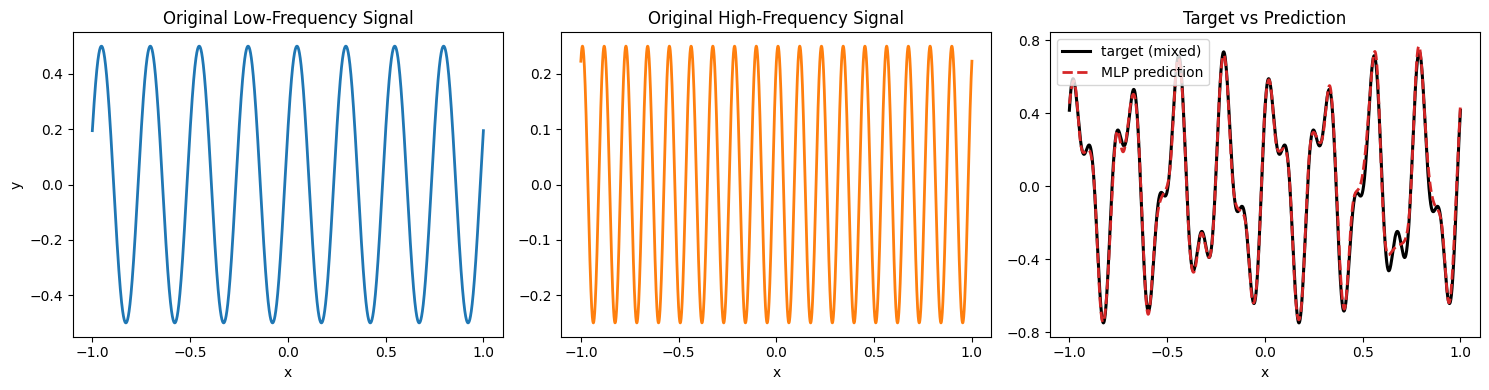

In [24]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


def plot_signals_breakdown(x_np, y_low_np, y_high_np, y_target_np, y_pred_np):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. 绘制原始低频信号
    axes[0].plot(x_np, y_low_np, color="tab:blue", linewidth=2)
    axes[0].set_title("Original Low-Frequency Signal")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0])

    # 2. 绘制原始高频信号
    axes[1].plot(x_np, y_high_np, color="tab:orange", linewidth=2)
    axes[1].set_title("Original High-Frequency Signal")
    axes[1].set_xlabel("x")
    axes[1].set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0])

    # 3. 绘制混合后的目标信号与MLP拟合信号的对比
    axes[2].plot(x_np, y_target_np, color="black", linewidth=2.2, label="target (mixed)")
    axes[2].plot(x_np, y_pred_np, color="tab:red", linewidth=2, linestyle="--", label="MLP prediction")
    axes[2].set_title("Target vs Prediction")
    axes[2].set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0])
    axes[2].set_yticks([-0.8, -0.4, 0.0, 0.4, 0.8])
    axes[2].set_xlabel("x")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig("./fig/signal_breakdown.pdf", format="pdf")
    plt.show()

plot_signals_breakdown(
    x_np=x_test_np,
    y_low_np=y_test_low_np,
    y_high_np=y_test_high_np,
    y_target_np=y_test_np,
    y_pred_np=y_pred_np
)

正在提取 25000 步之后的频率成分，请稍候...


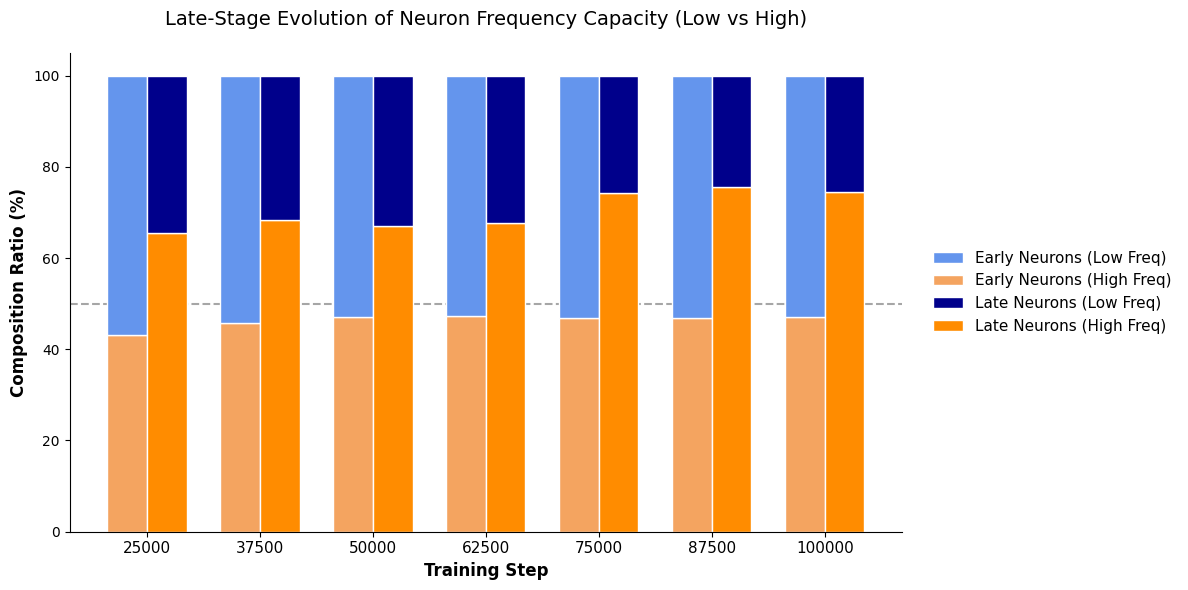

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def extract_dynamic_frequency_ratio_late_stage(early_ids, late_ids, layer_index=1, num_samples=12, min_step=25000):
    """
    提取指定步数（默认25000步）之后，早晚两组神经元各自输出的高频/低频能量比例。
    """
    records = []
    
    # 1. 过滤出大于等于 min_step 的所有步数索引
    valid_indices = [i for i, step in enumerate(sampled_steps) if step >= min_step]
    
    if not valid_indices:
        raise ValueError(f"在历史记录中没有找到大于等于 {min_step} 的步数！")
        
    # 2. 在这些有效的后期索引中，均匀采样 num_samples 个点
    step_indices = np.linspace(valid_indices[0], valid_indices[-1], num_samples, dtype=int)
    
    print(f"正在提取 {min_step} 步之后的频率成分，请稍候...")
    for idx in step_indices:
        step = sampled_steps[idx]
        
        # 提取早期神经元组的投影比例
        e_res = get_group_retained_result(
            neuron_ids=early_ids, 
            group_name="Early", 
            ckpt_idx=idx, 
            layer_index=layer_index
        )
        e_low = e_res["abs_low_fraction"]
        e_high = e_res["abs_high_fraction"]
        e_total = e_low + e_high + 1e-12
        
        records.append({
            "Step": str(step),
            "Group": "Early",
            "Low_Ratio": (e_low / e_total) * 100,
            "High_Ratio": (e_high / e_total) * 100,
            "Total_Energy": e_total
        })
        
        # 提取晚期神经元组的投影比例
        l_res = get_group_retained_result(
            neuron_ids=late_ids, 
            group_name="Late", 
            ckpt_idx=idx, 
            layer_index=layer_index
        )
        l_low = l_res["abs_low_fraction"]
        l_high = l_res["abs_high_fraction"]
        l_total = l_low + l_high + 1e-12
        
        records.append({
            "Step": str(step),
            "Group": "Late",
            "Low_Ratio": (l_low / l_total) * 100,
            "High_Ratio": (l_high / l_total) * 100,
            "Total_Energy": l_total
        })
        
    return pd.DataFrame(records)


def plot_frequency_evolution_grouped_stacked_bars(df_ratio):
    """
    绘制随时间演变的分组百分百堆叠柱状图 (低频/高频比例)
    """
    steps = df_ratio["Step"].unique()
    x = np.arange(len(steps))
    width = 0.35  
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = {
        "Early_Low": "cornflowerblue",
        "Early_High": "sandybrown",
        "Late_Low": "darkblue",
        "Late_High": "darkorange"
    }

    for i, step in enumerate(steps):
        early_data = df_ratio[(df_ratio["Step"] == step) & (df_ratio["Group"] == "Early")]
        late_data = df_ratio[(df_ratio["Step"] == step) & (df_ratio["Group"] == "Late")]
        
        if not early_data.empty:
            e_low = early_data["Low_Ratio"].values[0]
            e_high = early_data["High_Ratio"].values[0]
            
            # 先画底层(High)
            ax.bar(x[i] - width/2, e_high, width, color=colors["Early_High"], edgecolor='white', linewidth=1)
            # 再画顶层(Low)，指定 bottom=e_high
            ax.bar(x[i] - width/2, e_low, width, bottom=e_high, color=colors["Early_Low"], edgecolor='white', linewidth=1)
            
        if not late_data.empty:
            l_low = late_data["Low_Ratio"].values[0]
            l_high = late_data["High_Ratio"].values[0]
            
            # 先画底层(High)
            ax.bar(x[i] + width/2, l_high, width, color=colors["Late_High"], edgecolor='white', linewidth=1)
            # 再画顶层(Low)，指定 bottom=l_high
            ax.bar(x[i] + width/2, l_low, width, bottom=l_high, color=colors["Late_Low"], edgecolor='white', linewidth=1)

    ax.set_ylabel("Composition Ratio (%)", fontsize=12, fontweight='bold')
    ax.set_xlabel("Training Step", fontsize=12, fontweight='bold')
    ax.set_title("Late-Stage Evolution of Neuron Frequency Capacity (Low vs High)", fontsize=14, pad=20)
    
    ax.set_xticks(x)
    ax.set_xticklabels(steps, fontsize=11, rotation=0)
    ax.axhline(50, color='gray', linestyle='--', alpha=0.7, linewidth=1.5, zorder=0)

    legend_elements = [
        Patch(facecolor=colors["Early_Low"], edgecolor='white', label='Early Neurons (Low Freq)'),
        Patch(facecolor=colors["Early_High"], edgecolor='white', label='Early Neurons (High Freq)'),
        Patch(facecolor=colors["Late_Low"], edgecolor='white', label='Late Neurons (Low Freq)'),
        Patch(facecolor=colors["Late_High"], edgecolor='white', label='Late Neurons (High Freq)')
    ]
    
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig("./fig/frequency_evolution_late_stage.pdf", format="pdf")
    plt.show()


# ================= 运行执行 =================

# 1. 提取 25000 步之后的比例数据 (采样12个点)
df_freq_evolution_late = extract_dynamic_frequency_ratio_late_stage(
    early_ids=group_ids["early"],
    late_ids=group_ids["late"],
    layer_index=analysis_layer_index,
    num_samples=7,
    min_step=25000  # 设定起始步数
)

# 2. 绘制进化图
plot_frequency_evolution_grouped_stacked_bars(df_ratio=df_freq_evolution_late)

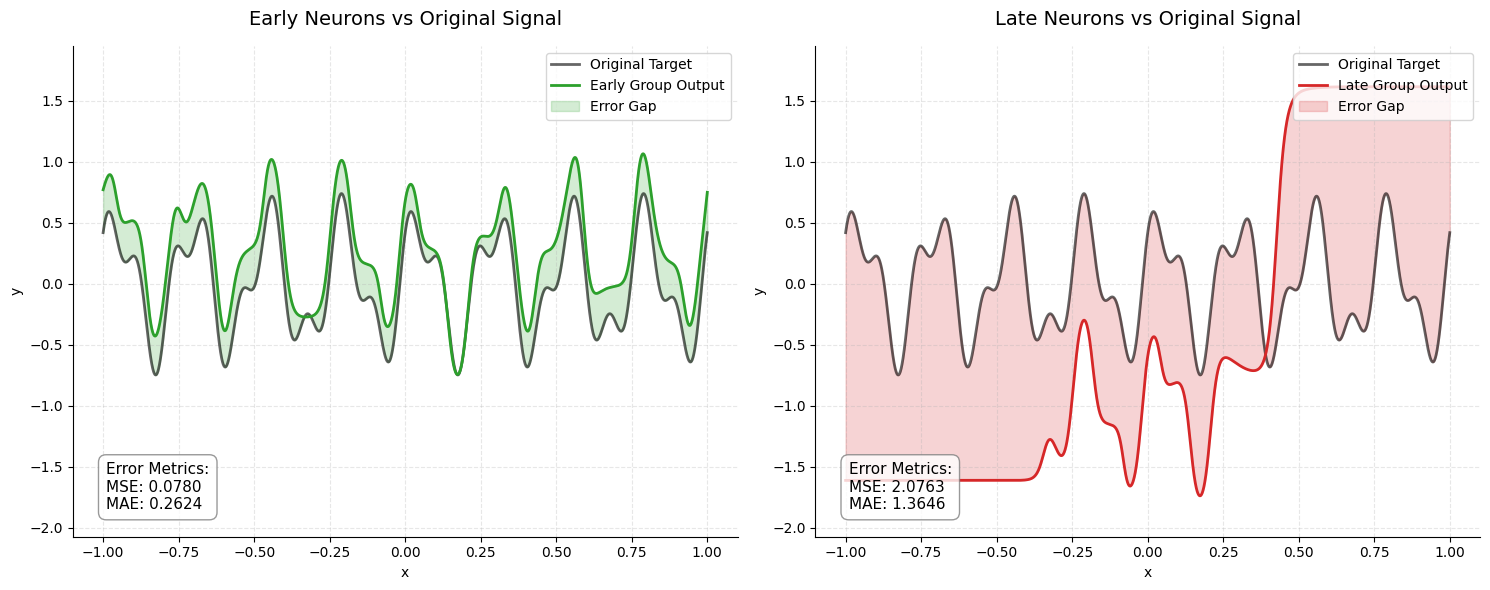

In [26]:
def plot_group_raw_fitting_with_error(x_np, y_target_np, early_result, late_result):
    """
    绘制早期组和晚期组的原始保留输出与混合目标信号的对比。
    并在图表上通过“阴影面积”和“文本框”直观展示误差大小 (MSE/MAE)。
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # 将数据展平，避免 matplotlib 绘图时的维度广播警告
    x_flat = x_np.reshape(-1)
    y_target = y_target_np.reshape(-1)
    y_early = early_result["y_group"].reshape(-1)
    y_late = late_result["y_group"].reshape(-1)

    # ---------------- 误差计算 ----------------
    def calc_metrics(y_true, y_pred):
        mse = np.mean((y_pred - y_true) ** 2)
        mae = np.mean(np.abs(y_pred - y_true))
        return mse, mae

    mse_early, mae_early = calc_metrics(y_target, y_early)
    mse_late, mae_late = calc_metrics(y_target, y_late)

    # ---------------- 左图：早期神经元 ----------------
    axes[0].plot(x_flat, y_target, color='black', alpha=0.6, linewidth=2, label='Original Target')
    axes[0].plot(x_flat, y_early, color='tab:green', linewidth=2, label='Early Group Output')
    
    # 用半透明绿色填充两条曲线之间的误差面积
    axes[0].fill_between(x_flat, y_target, y_early, color='tab:green', alpha=0.2, label='Error Gap')
    
    axes[0].set_title('Early Neurons vs Original Signal', fontsize=14, pad=15)
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].legend(loc="upper right")
    
    # 添加误差统计文本框
    text_early = f"Error Metrics:\nMSE: {mse_early:.4f}\nMAE: {mae_early:.4f}"
    axes[0].text(0.05, 0.05, text_early, transform=axes[0].transAxes, fontsize=11,
                 verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

    # ---------------- 右图：晚期神经元 ----------------
    axes[1].plot(x_flat, y_target, color='black', alpha=0.6, linewidth=2, label='Original Target')
    axes[1].plot(x_flat, y_late, color='tab:red', linewidth=2, label='Late Group Output')
    
    # 用半透明红色填充两条曲线之间的误差面积
    axes[1].fill_between(x_flat, y_target, y_late, color='tab:red', alpha=0.2, label='Error Gap')
    
    axes[1].set_title('Late Neurons vs Original Signal', fontsize=14, pad=15)
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].legend(loc="upper right")
    
    # 添加误差统计文本框
    text_late = f"Error Metrics:\nMSE: {mse_late:.4f}\nMAE: {mae_late:.4f}"
    axes[1].text(0.05, 0.05, text_late, transform=axes[1].transAxes, fontsize=11,
                 verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

    # ---------------- 坐标轴对其与美化 ----------------
    y_min = min(y_target.min(), y_early.min(), y_late.min())
    y_max = max(y_target.max(), y_early.max(), y_late.max())
    margin = (y_max - y_min) * 0.1
    
    axes[0].set_ylim(y_min - margin, y_max + margin)
    axes[1].set_ylim(y_min - margin, y_max + margin)

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

# ================= 运行执行 =================
# 调用该函数，直接传入你现有的变量：
plot_group_raw_fitting_with_error(x_test_np, y_test_np, early_result, late_result)


Target step: 20000 | actual checkpoint step: 20000

early_full
n_neurons: 18
abs low fraction: 0.7221671342849731
abs high fraction: 0.2254503220319748
frequency selectivity: -0.5241744006943855

late_full
n_neurons: 18
abs low fraction: 0.024939769878983498
abs high fraction: 0.02243228070437908
frequency selectivity: -0.05293182675592543


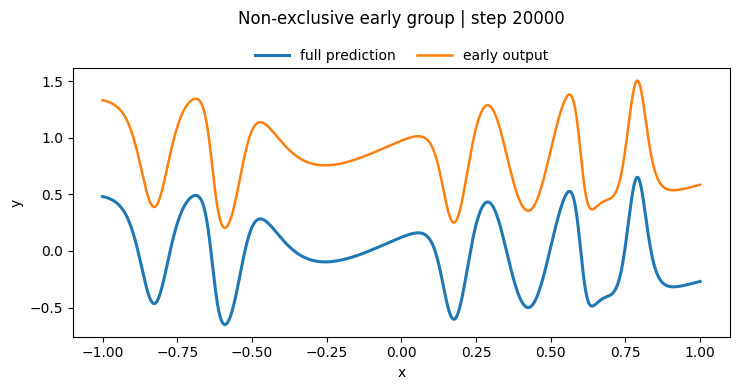

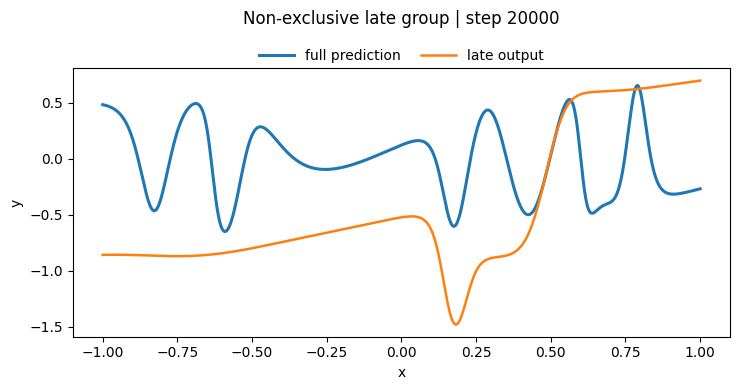

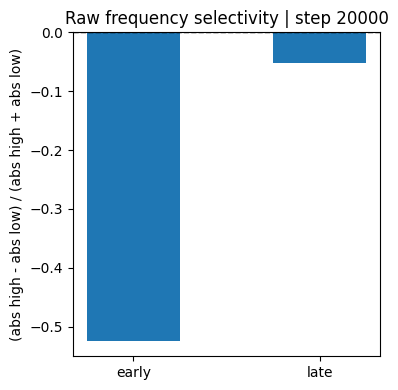


Target step: 40000 | actual checkpoint step: 40000

early_full
n_neurons: 18
abs low fraction: 1.0214898586273193
abs high fraction: 0.8725268840789795
frequency selectivity: -0.07864923851486806

late_full
n_neurons: 18
abs low fraction: 0.11739101260900497
abs high fraction: 0.2412021905183792
frequency selectivity: 0.3452691708298976


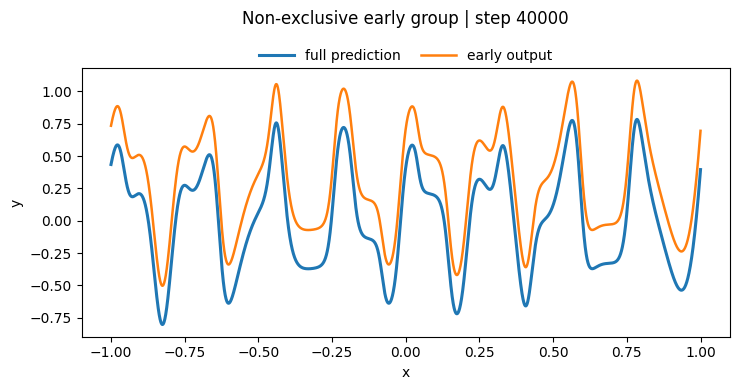

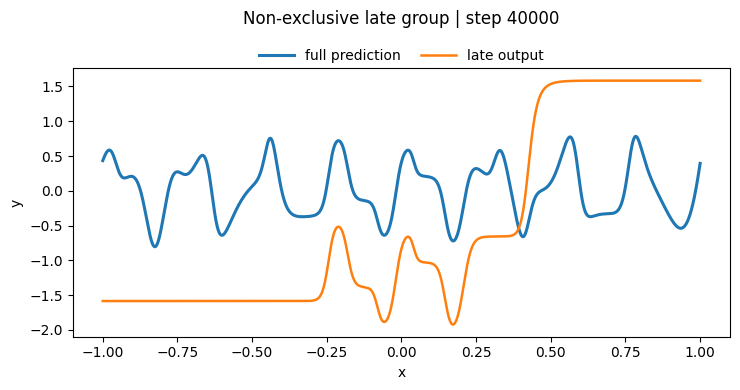

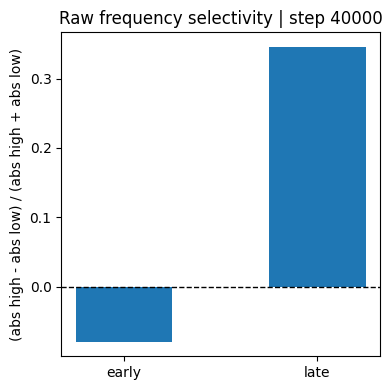


Target step: 60000 | actual checkpoint step: 60000

early_full
n_neurons: 18
abs low fraction: 1.0129351615905762
abs high fraction: 0.9130732417106628
frequency selectivity: -0.05184916104659513

late_full
n_neurons: 18
abs low fraction: 0.13183364272117615
abs high fraction: 0.24653059244155884
frequency selectivity: 0.3031389837116826


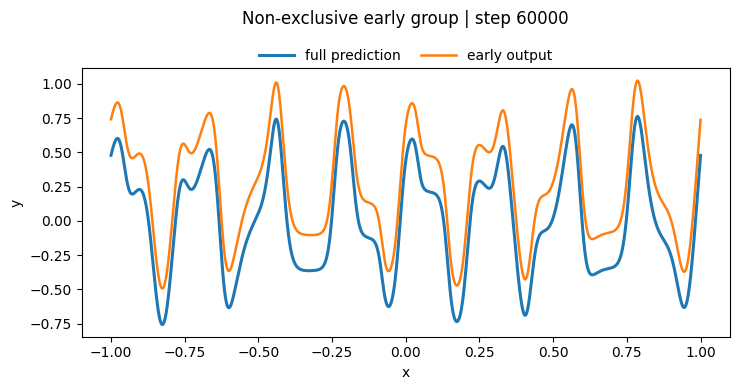

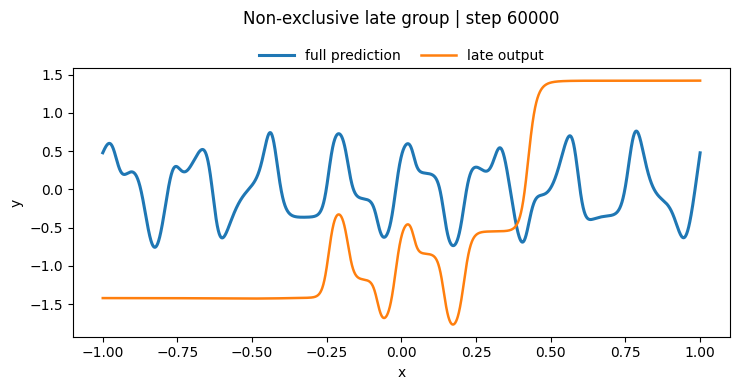

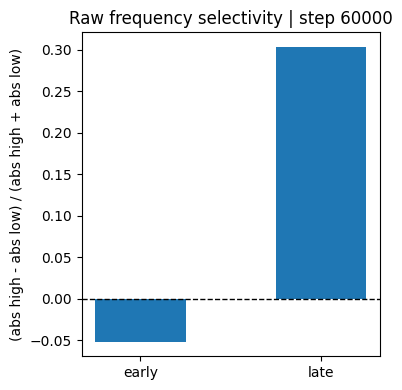


Target step: 80000 | actual checkpoint step: 80000

early_full
n_neurons: 18
abs low fraction: 1.0407463312149048
abs high fraction: 0.92146897315979
frequency selectivity: -0.060787089871905994

late_full
n_neurons: 18
abs low fraction: 0.0832822248339653
abs high fraction: 0.26738491654396057
frequency selectivity: 0.5250069652549982


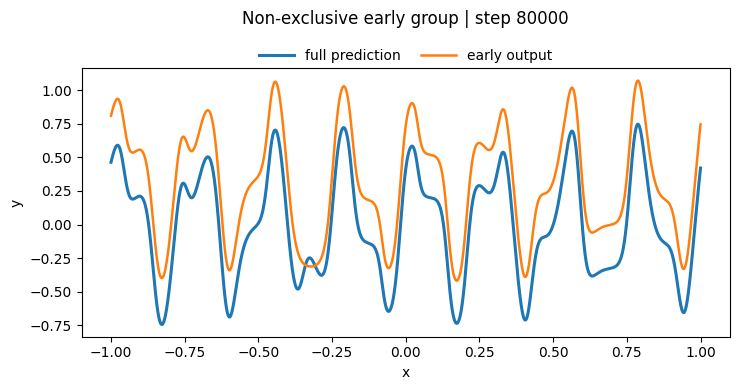

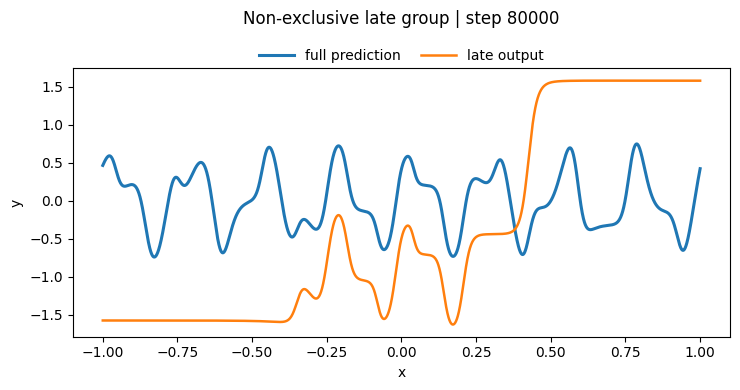

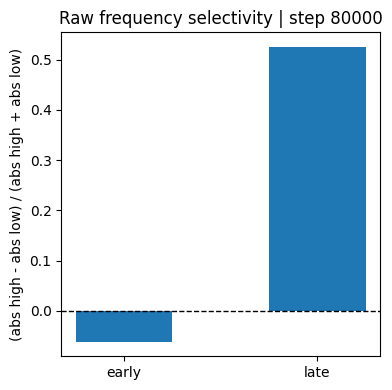


Target step: 100000 | actual checkpoint step: 100000

early_full
n_neurons: 18
abs low fraction: 1.0451841354370117
abs high fraction: 0.9282152652740479
frequency selectivity: -0.059272780827215266

late_full
n_neurons: 18
abs low fraction: 0.09068171679973602
abs high fraction: 0.26367008686065674
frequency selectivity: 0.4881825583318404


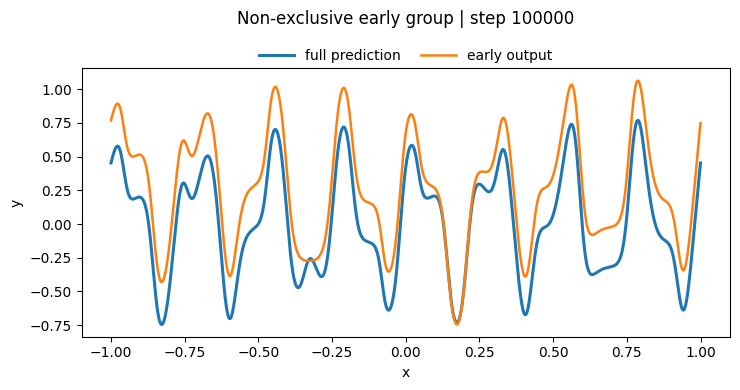

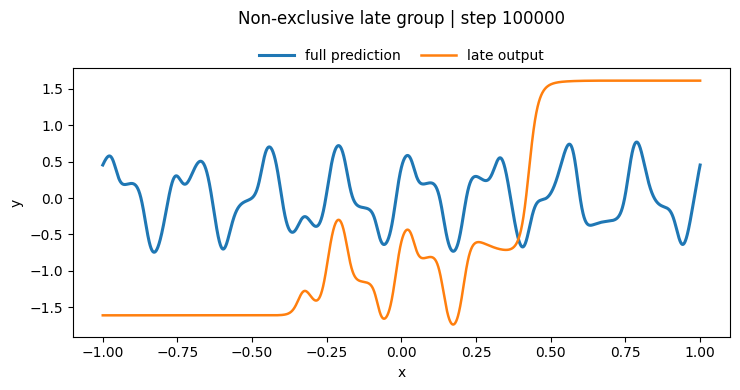

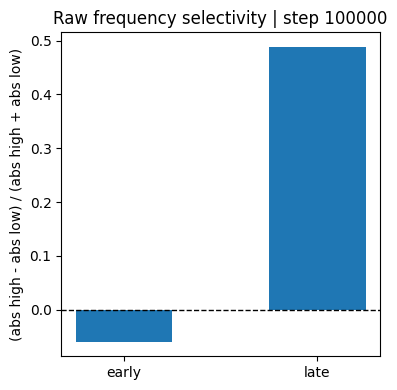

In [7]:
def ckpt_index_from_step(target_step, sampled_steps):
    sampled_steps_arr = np.asarray(sampled_steps)
    idx = int(np.argmin(np.abs(sampled_steps_arr - target_step)))
    return idx


def get_group_results_at_step(
    target_step,
    early_group_ids,
    late_group_ids,
    layer_index=1
):
    ckpt_idx = ckpt_index_from_step(target_step, sampled_steps)
    actual_step = int(sampled_steps[ckpt_idx])

    early_set = set(map(int, early_group_ids))
    late_set = set(map(int, late_group_ids))

    early_only_ids = sorted(list(early_set - late_set))
    late_only_ids = sorted(list(late_set - early_set))

    results = {
        "early_full": get_group_retained_result(
            neuron_ids=sorted(list(early_set)),
            group_name="early_full",
            ckpt_idx=ckpt_idx,
            layer_index=layer_index
        ),
        "late_full": get_group_retained_result(
            neuron_ids=sorted(list(late_set)),
            group_name="late_full",
            ckpt_idx=ckpt_idx,
            layer_index=layer_index
        ),
        "early_only": get_group_retained_result(
            neuron_ids=early_only_ids,
            group_name="early_only",
            ckpt_idx=ckpt_idx,
            layer_index=layer_index
        ),
        "late_only": get_group_retained_result(
            neuron_ids=late_only_ids,
            group_name="late_only",
            ckpt_idx=ckpt_idx,
            layer_index=layer_index
        )
    }

    return actual_step, results


def plot_group_output_vs_prediction_at_step(
    result,
    title,
    output_label,
    actual_step,
    figsize=(7.5, 4)
):
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        x_test_np,
        result["y_full"],
        linewidth=2.2,
        label="full prediction"
    )

    ax.plot(
        x_test_np,
        result["y_group"],
        linewidth=1.8,
        label=output_label
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title + " | step " + str(actual_step), pad=32)

    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=2,
        frameon=False,
        handlelength=2.5,
        columnspacing=1.5,
        borderaxespad=0.0
    )

    fig.tight_layout()
    plt.show()


def plot_two_nonexclusive_group_outputs_at_step(actual_step, results):
    plot_group_output_vs_prediction_at_step(
        result=results["early_full"],
        title="Non-exclusive early group",
        output_label="early output",
        actual_step=actual_step
    )

    plot_group_output_vs_prediction_at_step(
        result=results["late_full"],
        title="Non-exclusive late group",
        output_label="late output",
        actual_step=actual_step
    )


def plot_nonexclusive_selectivity_at_step(actual_step, results):
    group_order = ["early_full", "late_full"]
    labels = ["early", "late"]

    selectivity = [
        results[g]["frequency_selectivity"]
        for g in group_order
    ]

    x = np.arange(len(group_order))

    fig, ax = plt.subplots(figsize=(4, 4))

    ax.bar(x, selectivity, width=0.5)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("(abs high - abs low) / (abs high + abs low)")
    ax.set_title("Raw frequency selectivity | step " + str(actual_step))

    fig.tight_layout()
    plt.show()


def run_stepwise_nonexclusive_output_and_selectivity_analysis(
    step_list=(20000, 40000, 60000, 80000, 100000),
    layer_index=1
):
    all_step_results = {}

    for target_step in step_list:
        actual_step, results = get_group_results_at_step(
            target_step=target_step,
            early_group_ids=early_group_ids,
            late_group_ids=late_group_ids,
            layer_index=layer_index
        )

        print("")
        print("=" * 80)
        print("Target step:", target_step, "| actual checkpoint step:", actual_step)
        print("=" * 80)

        for name in ["early_full", "late_full"]:
            r = results[name]
            print("")
            print(name)
            print("n_neurons:", r["n_neurons"])
            print("abs low fraction:", r["abs_low_fraction"])
            print("abs high fraction:", r["abs_high_fraction"])
            print("frequency selectivity:", r["frequency_selectivity"])

        plot_two_nonexclusive_group_outputs_at_step(
            actual_step=actual_step,
            results=results
        )

        plot_nonexclusive_selectivity_at_step(
            actual_step=actual_step,
            results=results
        )

        all_step_results[actual_step] = {
            "early_full": results["early_full"],
            "late_full": results["late_full"]
        }

    return all_step_results


stepwise_nonexclusive_results = run_stepwise_nonexclusive_output_and_selectivity_analysis(
    step_list=(20000, 40000, 60000, 80000, 100000),
    layer_index=1
)


Exclusive group summary:
early only: [3, 4, 5, 6, 10, 13, 17, 23, 24, 29]
late only: [0, 2, 8, 12, 15, 21, 22, 25, 26, 27]
overlap: [7, 9, 11, 16, 18, 19, 20, 28]


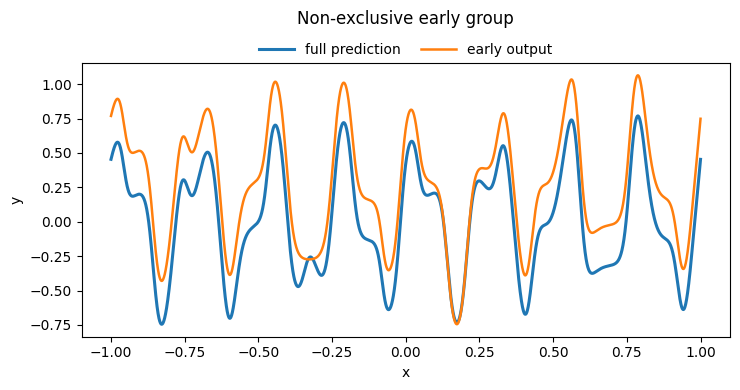

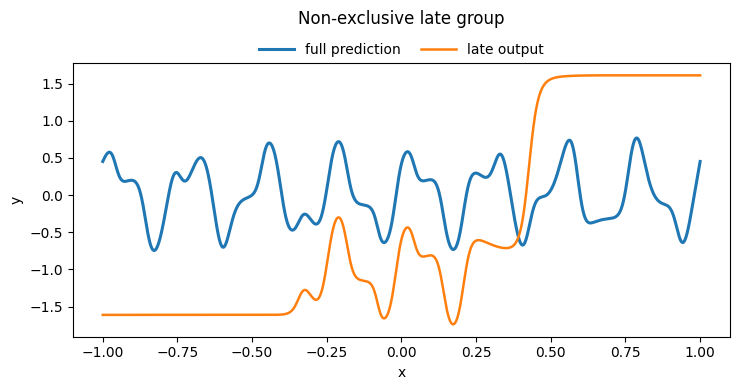

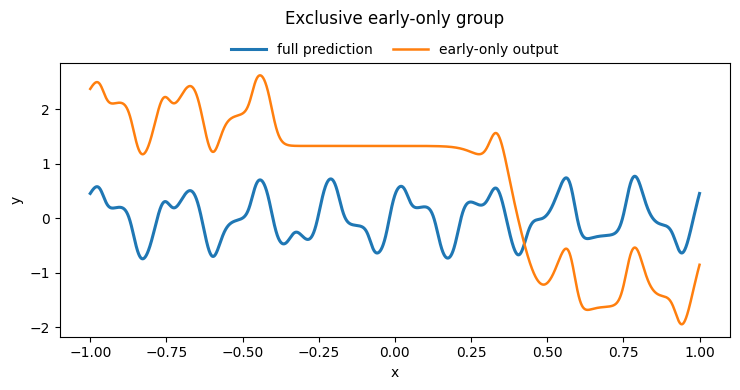

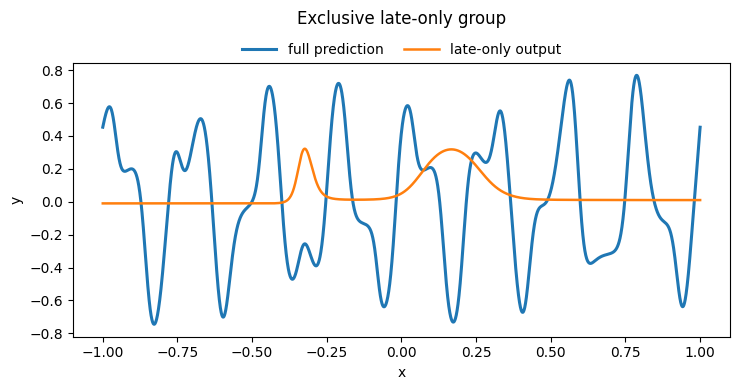

In [7]:
def ensure_exclusive_group_results(
    early_group_ids,
    late_group_ids,
    ckpt_idx=-1,
    layer_index=1
):
    early_set = set(map(int, early_group_ids))
    late_set = set(map(int, late_group_ids))

    early_only_ids = sorted(list(early_set - late_set))
    late_only_ids = sorted(list(late_set - early_set))
    overlap_ids = sorted(list(early_set & late_set))

    print("")
    print("Exclusive group summary:")
    print("early only:", early_only_ids)
    print("late only:", late_only_ids)
    print("overlap:", overlap_ids)

    early_only_result = get_group_retained_result(
        neuron_ids=early_only_ids,
        group_name="early_only",
        ckpt_idx=ckpt_idx,
        layer_index=layer_index
    )

    late_only_result = get_group_retained_result(
        neuron_ids=late_only_ids,
        group_name="late_only",
        ckpt_idx=ckpt_idx,
        layer_index=layer_index
    )

    return early_only_result, late_only_result


def plot_group_output_vs_prediction_only(
    result,
    title,
    output_label,
    figsize=(7.5, 4)
):
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        x_test_np,
        result["y_full"],
        linewidth=2.2,
        label="full prediction"
    )

    ax.plot(
        x_test_np,
        result["y_group"],
        linewidth=1.8,
        label=output_label
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)

    ax.set_title(title, pad=28)

    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=2,
        frameon=False,
        handlelength=2.5,
        columnspacing=1.5,
        borderaxespad=0.0
    )

    fig.tight_layout()
    plt.show()


early_only_result, late_only_result = ensure_exclusive_group_results(
    early_group_ids=early_group_ids,
    late_group_ids=late_group_ids,
    ckpt_idx=-1,
    layer_index=1
)


plot_group_output_vs_prediction_only(
    result=early_result,
    title="Non-exclusive early group",
    output_label="early output"
)

plot_group_output_vs_prediction_only(
    result=late_result,
    title="Non-exclusive late group",
    output_label="late output"
)

plot_group_output_vs_prediction_only(
    result=early_only_result,
    title="Exclusive early-only group",
    output_label="early-only output"
)

plot_group_output_vs_prediction_only(
    result=late_only_result,
    title="Exclusive late-only group",
    output_label="late-only output"
)